# Used-car price prediction — Polish market

**Question → analysis → conclusion.** EDA on ~118k Polish used-car adverts, the feature
choices that follow from it, a model bake-off, and what drives a valuation (SHAP).

**Data:** [Car Prices Poland](https://www.kaggle.com/datasets/aleksandrglotov/car-prices-poland)
(aleksandrglotov, Kaggle, **CC0**). See `docs/research/data-and-methodology.md`.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from car_price_ml import config, data, features, model

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = data.load_clean()
print(f"Clean rows: {len(df):,}  |  marks: {df['mark'].nunique()}  |  models: {df['model'].nunique()}")
df[["mark", "model", "year", "mileage", "vol_engine", "fuel", "province", "price"]].head()

Clean rows: 117,859  |  marks: 23  |  models: 328


,mark,model,year,mileage,vol_engine,fuel,province,price
0,opel,combo,2015,139568,1248,Diesel,Mazowieckie,35900
1,opel,combo,2018,31991,1499,Diesel,Śląskie,78501
2,opel,combo,2015,278437,1598,Diesel,Opolskie,27000
3,opel,combo,2016,47600,1248,Diesel,Opolskie,30800
4,opel,combo,2014,103000,1400,CNG,Śląskie,35900


## Q1 — How is price distributed?

Used-car prices are strongly right-skewed (many cheap cars, few expensive). That's why we
train on `log1p(price)` and invert before reporting metrics.

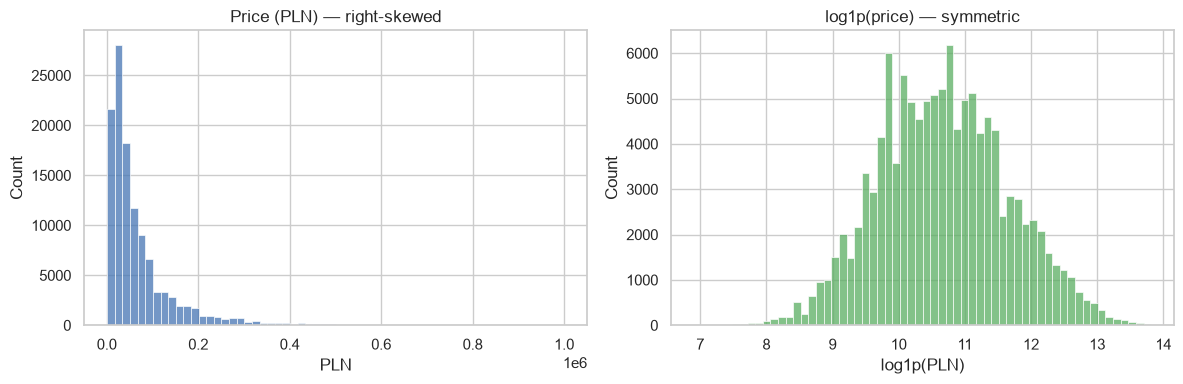

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=60, ax=axes[0], color="#4575b4")
axes[0].set(title="Price (PLN) — right-skewed", xlabel="PLN")
sns.histplot(np.log1p(df["price"]), bins=60, ax=axes[1], color="#5aae61")
axes[1].set(title="log1p(price) — symmetric", xlabel="log1p(PLN)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "fig1_price_dist.png", dpi=110)
plt.show()

**Conclusion (Q1):** the log transform symmetrizes the target — a prerequisite for a
well-behaved regression and for MAPE-style relative error.

## Q2 — How does price depend on age and mileage?

Depreciation is **front-loaded and non-linear** — the reason tree models beat a linear
baseline here.

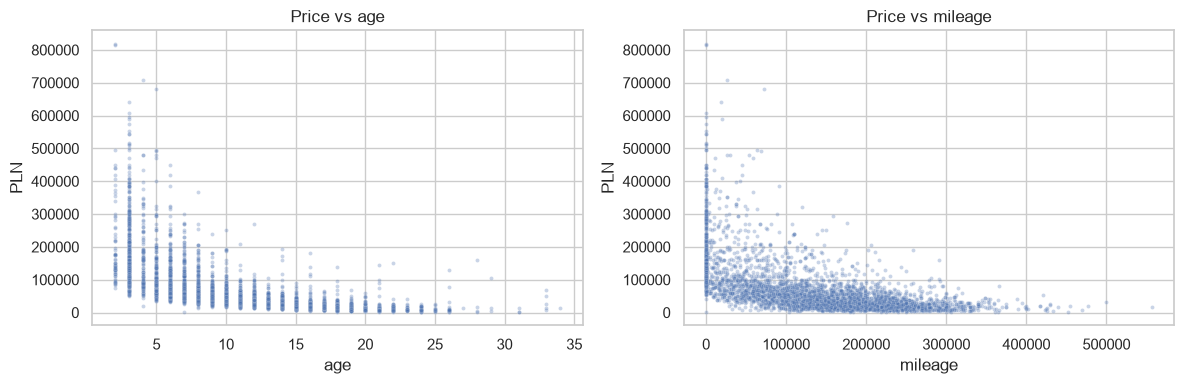

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = df.sample(4000, random_state=config.RANDOM_STATE)
sns.scatterplot(data=sample, x="age", y="price", ax=axes[0], s=8, alpha=0.3)
axes[0].set(title="Price vs age", ylabel="PLN")
sns.scatterplot(data=sample, x="mileage", y="price", ax=axes[1], s=8, alpha=0.3)
axes[1].set(title="Price vs mileage", ylabel="PLN")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "fig2_depreciation.png", dpi=110)
plt.show()

**Conclusion (Q2):** price falls steeply then flattens with both age and mileage —
convex, not linear. Linear models need transforms; trees capture this natively.

## Feature engineering (what the EDA implies)

- **`age = reference_year − year`** (not raw year — avoids drift/leakage).
- **Out-of-fold target encoding** for high-cardinality `mark`/`model` (leakage-safe).
- One-hot for low-cardinality `fuel`/`province`; numerics pass through.
- **`log1p(price)`** target, inverted before metrics.

## Model bake-off

Linear baseline vs. two tree ensembles, 5-fold CV, metrics in PLN. Run here on a sample
for speed; the full-data result (committed with the model) is **RandomForest MAE ≈ 8,616
PLN, MAPE 14.3%, R² 0.944**.

In [4]:
sample = df.sample(30000, random_state=config.RANDOM_STATE)
X_s, y_s = features.prepare(sample)
bake = model.cross_validate_models(X_s, y_s, n_splits=5)
import pandas as pd
pd.DataFrame(bake).T[["mae", "rmse", "mape", "r2"]].sort_values("mae")

,mae,rmse,mape,r2
LightGBM,10117.9,23308.0,16.03,0.9222
RandomForest,10172.5,23690.4,16.39,0.9196
Ridge,15572.4,33292.3,23.15,0.8413


**Conclusion (bake-off):** tree ensembles roughly halve the linear baseline's error
(R² ~0.94 vs ~0.84) — the non-linear depreciation curve is exactly where trees win
(Grinsztajn et al., NeurIPS 2022).

## What drives a valuation? (SHAP)

SHAP TreeExplainer on **LightGBM** (fast native SHAP; its bake-off score is close to the
RF winner) — preferred over impurity importance, which is biased toward high-cardinality
make/model.

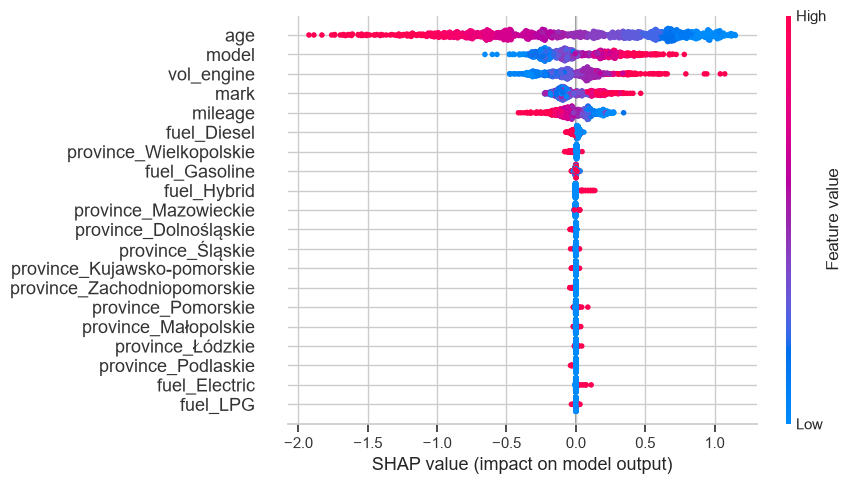

In [5]:
import shap
X_all, y_all = features.prepare(df)
lgbm = model.train(X_all, y_all, name="LightGBM")
X_sample = X_all.sample(1000, random_state=config.RANDOM_STATE)
shap_values, X_trans, names = model.shap_explanation(lgbm, X_sample)

shap.summary_plot(shap_values, X_trans, feature_names=names, show=False)
plt.gcf().set_size_inches(9, 5)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "fig3_shap.png", dpi=110, bbox_inches="tight")
plt.show()

**Conclusion (SHAP):** the encoded `mark`/`model`, `age` and `mileage` dominate a
valuation — the model learns the depreciation + brand-premium structure the EDA hinted at.

### Limitations
- Prices are ~2021–2023 — the model is **historically biased** vs. today's market.
- No `power`/`gearbox` in this dataset (a richer alternative exists — see the research doc).
- A fixed `reference_year` for `age` adds a constant offset (documented; harmless for
  relative comparisons).